# Esperimento 2: Gromov-Wasserstein — Data Flow con Dati Reali

Replica esatta dell'esperimento GW della pipeline, passo per passo,
sul dataset completo (~394 termini giuridici) con i modelli reali.

In [1]:
import sys, os, json
os.chdir(os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd())
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr
import ot
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

np.set_printoptions(precision=4, suppress=True)
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Step 0: Caricamento dati reali e embedding

Carichiamo il dataset completo e generiamo gli embedding
con la coppia di modelli di default (E5-large-v2 × BGE-ZH-v1.5).

In [2]:
from src.core.config_loader import load_config
from src.core.device import DeviceManager
from src.embeddings.client import EmbeddingClient

config = load_config('config.yaml')

# Dataset
data_path = config.get_absolute_path('processed') / 'legal_terms.json'
with open(data_path, encoding='utf-8') as f:
    data = json.load(f)

core_terms = data['core_terms']
en_core = [t['en'] for t in core_terms]
zh_core = [t['zh'] for t in core_terms]
labels = en_core  # etichette inglesi per leggibilità
domains = [t.get('domain', t.get('category', '?')) for t in core_terms]

n = len(core_terms)
print(f"Core terms: {n}")
print(f"Domini: {sorted(set(domains))}")
print(f"Primi 10: {labels[:10]}")

Core terms: 394
Domini: ['civil', 'constitutional', 'criminal', 'environmental_tech', 'governance', 'international', 'jurisprudence', 'labor_social', 'rights']
Primi 10: ['Sovereignty', 'Constitution', 'Democracy', 'Separation of Powers', 'Judicial Independence', 'Judicial Review', 'Rule of Law', 'Prerogative', 'Autonomy', 'Devolution']


/Users/gpuzio/Desktop/CODE/THESIS/cls_pipeline/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Embedding con i modelli reali (usa cache se disponibile)
device_manager = DeviceManager(config.device.preferred)
client = EmbeddingClient(config, device_manager)

weird_cfg = config.models['weird']
sinic_cfg = config.models['sinic']
print(f"Modello WEIRD: {weird_cfg.name}")
print(f"Modello Sinic: {sinic_cfg.name}")

emb_w = client.get_embeddings(en_core, 'weird')
emb_s = client.get_embeddings(zh_core, 'sinic')

print(f"\nEmbedding WEIRD: {emb_w.shape} (dim={emb_w.shape[1]})")
print(f"Embedding Sinic: {emb_s.shape} (dim={emb_s.shape[1]})")
print(f"\nNorma media WEIRD: {np.linalg.norm(emb_w, axis=1).mean():.4f}")
print(f"Norma media Sinic: {np.linalg.norm(emb_s, axis=1).mean():.4f}")

client.unload_models()

Modello WEIRD: intfloat/e5-large-v2
Modello Sinic: BAAI/bge-large-zh-v1.5

Embedding WEIRD: (394, 1024) (dim=1024)
Embedding Sinic: (394, 1024) (dim=1024)

Norma media WEIRD: 1.0000
Norma media Sinic: 1.0000


## Step 1: Matrici di costo intra-spazio (C1, C2)

$$C_1[i,j] = 1 - \cos(\mathbf{x}_i, \mathbf{x}_j) \quad\quad C_2[i,j] = 1 - \cos(\mathbf{y}_i, \mathbf{y}_j)$$

Queste matrici descrivono la geometria interna di ciascun spazio.
Sono esattamente le stesse RDM usate in RSA — ma GW le usa diversamente.

C1 (WEIRD): (394, 394), range=[-0.0000, 0.3116]
C2 (Sinic): (394, 394), range=[-0.0000, 0.8795]
Coppie uniche: 77421


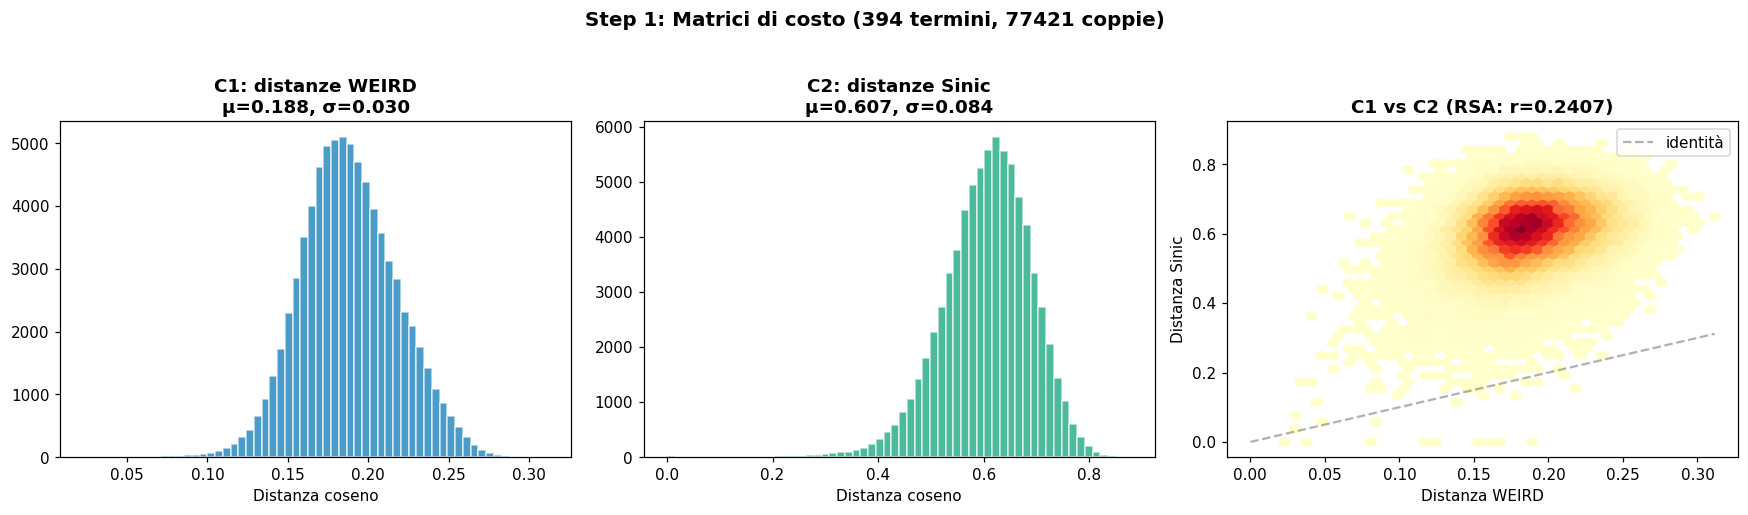

In [4]:
C1 = 1.0 - cosine_similarity(emb_w)
C2 = 1.0 - cosine_similarity(emb_s)

print(f"C1 (WEIRD): {C1.shape}, range=[{C1.min():.4f}, {C1.max():.4f}]")
print(f"C2 (Sinic): {C2.shape}, range=[{C2.min():.4f}, {C2.max():.4f}]")
print(f"Coppie uniche: {n*(n-1)//2}")

# Distribuzione delle distanze
triu = np.triu_indices(n, k=1)
d_w = C1[triu]
d_s = C2[triu]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(d_w, bins=60, alpha=0.7, color='#0072B2', edgecolor='white')
axes[0].set_title(f'C1: distanze WEIRD\nμ={d_w.mean():.3f}, σ={d_w.std():.3f}', fontweight='bold')
axes[0].set_xlabel('Distanza coseno')

axes[1].hist(d_s, bins=60, alpha=0.7, color='#009E73', edgecolor='white')
axes[1].set_title(f'C2: distanze Sinic\nμ={d_s.mean():.3f}, σ={d_s.std():.3f}', fontweight='bold')
axes[1].set_xlabel('Distanza coseno')

axes[2].hexbin(d_w, d_s, gridsize=40, cmap='YlOrRd', mincnt=1)
axes[2].plot([0, d_w.max()], [0, d_w.max()], 'k--', alpha=0.3, label='identità')
r_rdm, _ = spearmanr(d_w, d_s)
axes[2].set_title(f'C1 vs C2 (RSA: r={r_rdm:.4f})', fontweight='bold')
axes[2].set_xlabel('Distanza WEIRD')
axes[2].set_ylabel('Distanza Sinic')
axes[2].legend()

fig.suptitle(f'Step 1: Matrici di costo ({n} termini, {n*(n-1)//2} coppie)', fontsize=13, fontweight='bold', y=1.03)
fig.tight_layout()
plt.show()

## Step 2: Distribuzioni uniformi e parametri

Ogni termine ha peso $p_i = q_j = 1/n$. Usiamo $\varepsilon = 0.005$ (da config.yaml).

In [5]:
p = np.ones(n) / n
q = np.ones(n) / n

gw_config = config.experiments.gromov_wasserstein
epsilon = gw_config.entropic_reg

print(f"n termini:        {n}")
print(f"Peso per termine: {1/n:.6f}")
print(f"ε (entropic_reg): {epsilon}")
print(f"use_sinkhorn:     {gw_config.use_sinkhorn}")
print(f"n_permutations:   {gw_config.n_permutations}")

n termini:        394
Peso per termine: 0.002538
ε (entropic_reg): 0.005
use_sinkhorn:     True
n_permutations:   5000


## Step 3: Calcolo del Piano di Trasporto (T)

Questo è il cuore di GW. Minimizza:

$$\text{GW}_\varepsilon(C_1, C_2) = \min_T \left[ \sum_{i,j,k,l} (C_1[i,k] - C_2[j,l])^2 \cdot T[i,j] \cdot T[k,l] \;-\; \varepsilon \cdot H(T) \right]$$

Il piano T dice: per ogni termine WEIRD, su quale termine Sinic si mappa?

In [6]:
C1_64 = np.ascontiguousarray(C1, dtype=np.float64)
C2_64 = np.ascontiguousarray(C2, dtype=np.float64)

print("Calcolo GW (può richiedere ~30s)...")
T, gw_log = ot.gromov.entropic_gromov_wasserstein(
    C1_64, C2_64, p, q,
    loss_fun='square_loss',
    epsilon=epsilon,
    log=True,
)
gw_dist = gw_log['gw_dist']

print(f"\nGW distance = {gw_dist:.8f}")
print(f"T shape: {T.shape}")
print(f"T range: [{T.min():.8f}, {T.max():.8f}]")
print(f"T somma: {T.sum():.6f} (deve essere 1.0)")

# Verifica vincoli marginali
row_sums = T.sum(axis=1)
col_sums = T.sum(axis=0)
print(f"\nMargini riga:    min={row_sums.min():.6f}, max={row_sums.max():.6f} (atteso {1/n:.6f})")
print(f"Margini colonna: min={col_sums.min():.6f}, max={col_sums.max():.6f} (atteso {1/n:.6f})")

Calcolo GW (può richiedere ~30s)...

GW distance = 0.18173514
T shape: (394, 394)
T range: [0.00000000, 0.00022838]
T somma: 1.000000 (deve essere 1.0)

Margini riga:    min=0.002538, max=0.002538 (atteso 0.002538)
Margini colonna: min=0.002538, max=0.002538 (atteso 0.002538)


## Step 4: Struttura del Piano di Trasporto

Il piano T è una matrice 394×394: troppo grande per visualizzarla direttamente.
Analizziamo la sua struttura: è quasi-diagonale (mapping 1-a-1) o diffusa?

Entropia per riga: min=4.24, max=5.96, media=5.86
Entropia massima (uniforme): 5.98
Rapporto medio entropia/max: 97.97%

Peso massimo per riga: min=0.0028, max=0.0900, media=0.0056


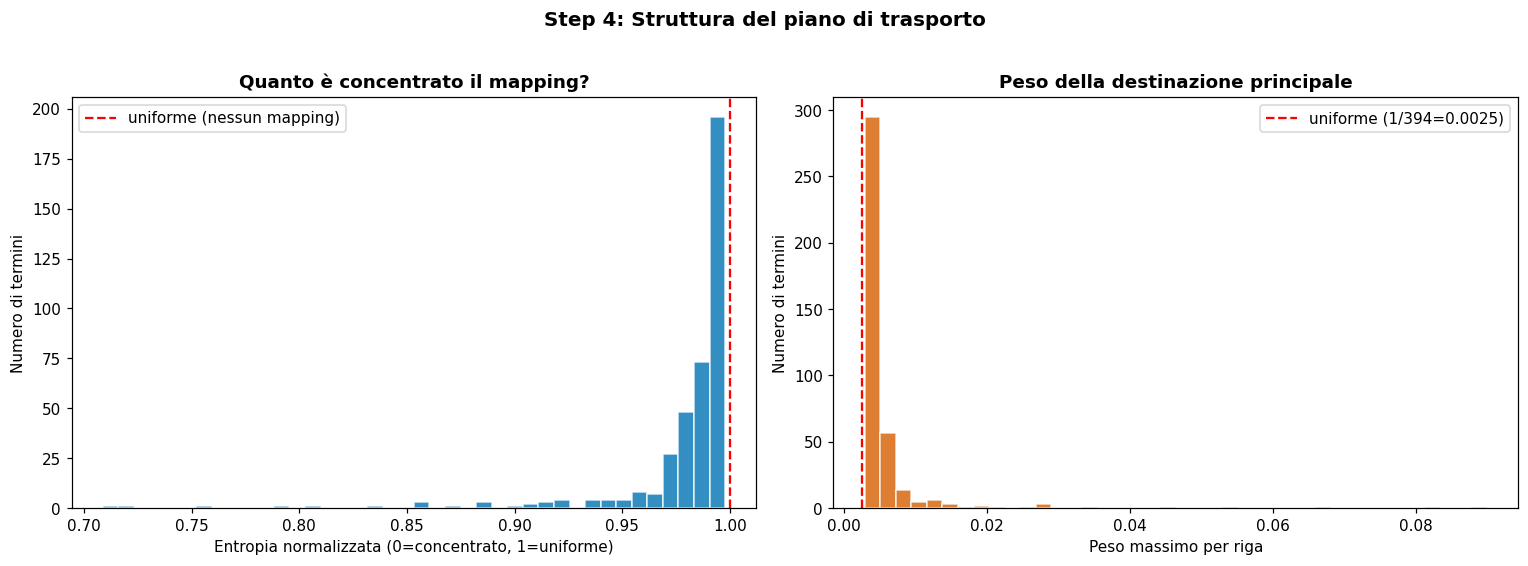

In [7]:
# Per ogni termine WEIRD, quanto è concentrato il mapping?
T_row_norm = T / T.sum(axis=1, keepdims=True)

# Entropia per riga: bassa = mapping concentrato, alta = diffuso
row_entropy = -np.sum(T_row_norm * np.log(T_row_norm + 1e-30), axis=1)
max_entropy = np.log(n)  # entropia massima (uniforme)

# Peso massimo per riga: alta = mapping quasi 1-a-1
max_weight = T_row_norm.max(axis=1)

print(f"Entropia per riga: min={row_entropy.min():.2f}, max={row_entropy.max():.2f}, media={row_entropy.mean():.2f}")
print(f"Entropia massima (uniforme): {max_entropy:.2f}")
print(f"Rapporto medio entropia/max: {(row_entropy / max_entropy).mean():.2%}")
print(f"\nPeso massimo per riga: min={max_weight.min():.4f}, max={max_weight.max():.4f}, media={max_weight.mean():.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(row_entropy / max_entropy, bins=40, color='#0072B2', edgecolor='white', alpha=0.8)
ax1.axvline(1.0, color='red', linestyle='--', label='uniforme (nessun mapping)')
ax1.set_xlabel('Entropia normalizzata (0=concentrato, 1=uniforme)')
ax1.set_ylabel('Numero di termini')
ax1.set_title('Quanto è concentrato il mapping?', fontweight='bold')
ax1.legend()

ax2.hist(max_weight, bins=40, color='#D55E00', edgecolor='white', alpha=0.8)
ax2.axvline(1/n, color='red', linestyle='--', label=f'uniforme (1/{n}={1/n:.4f})')
ax2.set_xlabel('Peso massimo per riga')
ax2.set_ylabel('Numero di termini')
ax2.set_title('Peso della destinazione principale', fontweight='bold')
ax2.legend()

fig.suptitle('Step 4: Struttura del piano di trasporto', fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

## Step 5: Top allineamenti — chi mappa su chi?

Le celle di T con massa più alta ci dicono quali concetti
vengono più fortemente allineati tra i due spazi.

In [8]:
# Top-K coppie per massa nel piano di trasporto
K = 30

flat_idx = np.argsort(T.ravel())[::-1][:K]
rows, cols = np.unravel_index(flat_idx, T.shape)

uniform_mass = 1 / (n * n)  # massa se T fosse uniforme

print(f"Top-{K} allineamenti (massa nel piano T):")
print(f"{'#':>3s}  {'EN (WEIRD)':<30s} {'ZH (Sinic)':<20s} {'Dominio':<18s} {'T[i,j]':>10s} {'×uniforme':>10s}")
print('-' * 95)
for rank, (i, j) in enumerate(zip(rows, cols)):
    mass = T[i, j]
    ratio = mass / uniform_mass
    match_str = '<<< SELF' if i == j else ''
    print(f"{rank+1:>3d}  {en_core[i]:<30s} {zh_core[j]:<20s} {domains[i]:<18s} {mass:>10.6f} {ratio:>9.1f}× {match_str}")

Top-30 allineamenti (massa nel piano T):
  #  EN (WEIRD)                     ZH (Sinic)           Dominio                T[i,j]  ×uniforme
-----------------------------------------------------------------------------------------------
  1  Laches                         难民中心                 jurisprudence        0.000228      35.5× 
  2  Intra Vires                    难民中心                 jurisprudence        0.000211      32.8× 
  3  Laches                         杀婴                   jurisprudence        0.000203      31.5× 
  4  Intra Vires                    杀婴                   jurisprudence        0.000189      29.4× 
  5  Democratic Centralism          难民中心                 jurisprudence        0.000168      26.1× 
  6  Democratic Centralism          杀婴                   jurisprudence        0.000154      23.9× 
  7  Laches                         碎股                   jurisprudence        0.000144      22.3× 
  8  Laches                         原居村民                 jurisprudence  

In [9]:
# Per ogni termine: il suo mapping principale è sé stesso (i→i)?
self_mapping = 0
mismatches = []
for i in range(n):
    best_j = np.argmax(T[i])
    if best_j == i:
        self_mapping += 1
    else:
        mismatches.append((i, best_j, T_row_norm[i, best_j]))

print(f"Termini che mappano su sé stessi (i→i): {self_mapping}/{n} ({self_mapping/n:.0%})")
print(f"Termini con mapping diverso: {len(mismatches)}")

if mismatches:
    mismatches.sort(key=lambda x: x[2], reverse=True)
    print(f"\nTop-20 mapping NON-self (dove la struttura diverge):")
    print(f"{'EN (WEIRD)':<30s} {'→ EN del target Sinic':<30s} {'prob':>6s} {'dom_src':<15s} {'dom_tgt':<15s}")
    print('-' * 100)
    for i, j, prob in mismatches[:20]:
        print(f"{en_core[i]:<30s} → {en_core[j]:<28s} {prob:>5.0%}  {domains[i]:<15s} {domains[j]:<15s}")

Termini che mappano su sé stessi (i→i): 1/394 (0%)
Termini con mapping diverso: 393

Top-20 mapping NON-self (dove la struttura diverge):
EN (WEIRD)                     → EN del target Sinic            prob dom_src         dom_tgt        
----------------------------------------------------------------------------------------------------
Laches                         → Refugee                         9%  jurisprudence   rights         
Intra Vires                    → Refugee                         8%  jurisprudence   rights         
Democratic Centralism          → Refugee                         7%  jurisprudence   rights         
Ultra Vires                    → Refugee                         5%  jurisprudence   rights         
Novation                       → Refugee                         5%  civil           rights         
Estoppel                       → Refugee                         3%  civil           rights         
Socialist Rule of Law          → Refugee              

## Step 6: Distorsioni strutturali per dominio

Per ogni coppia di termini, calcoliamo la distorsione:
$(C_1[i,k] - C_2[i,k])^2$ (assumendo mapping identità per semplicità).

Dove la distorsione è alta, i due modelli organizzano i concetti diversamente.

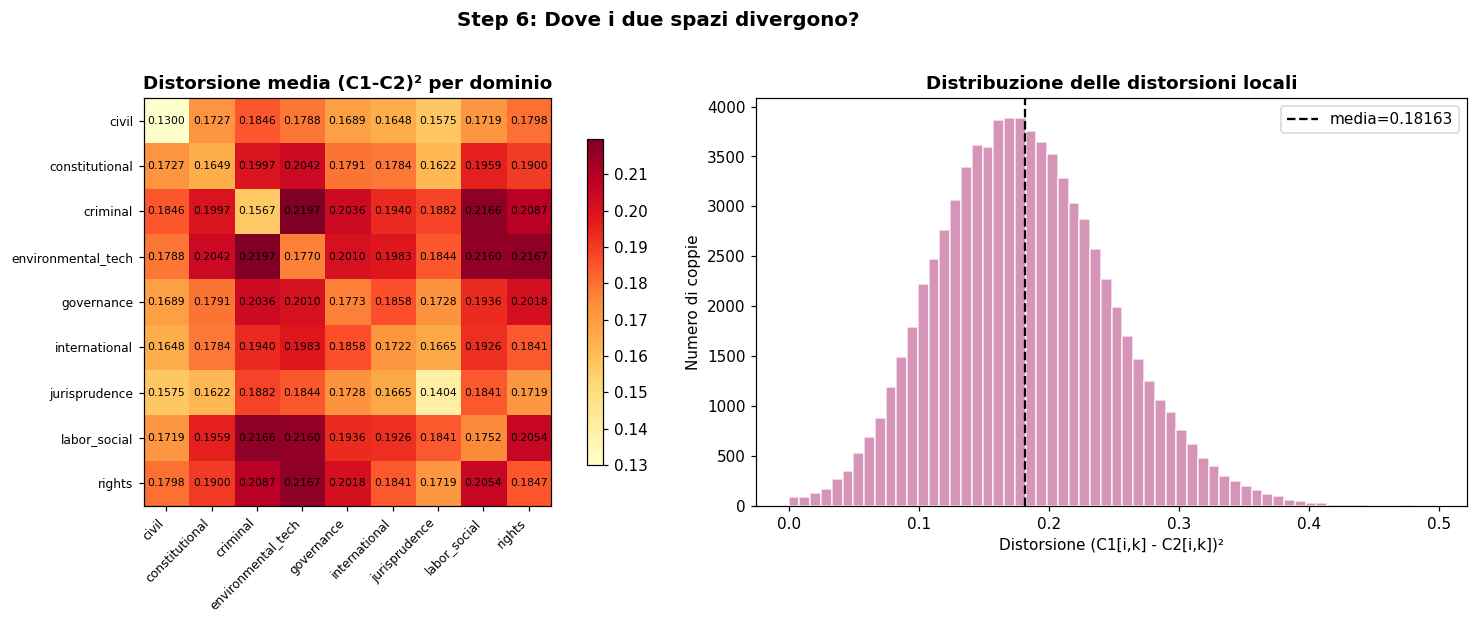

In [10]:
# Matrice di distorsione locale (mapping identità)
distortion_matrix = (C1 - C2) ** 2

# Distorsione media per dominio (intra e inter)
unique_domains = sorted(set(domains))
n_dom = len(unique_domains)
dom_idx = {d: [i for i, dd in enumerate(domains) if dd == d] for d in unique_domains}

# Matrice K×K di distorsione media tra domini
dom_distortion = np.zeros((n_dom, n_dom))
for di, d1 in enumerate(unique_domains):
    for dj, d2 in enumerate(unique_domains):
        idx1 = dom_idx[d1]
        idx2 = dom_idx[d2]
        block = distortion_matrix[np.ix_(idx1, idx2)]
        dom_distortion[di, dj] = block.mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

# Heatmap distorsione per dominio
im = ax1.imshow(dom_distortion, cmap='YlOrRd')
ax1.set_xticks(range(n_dom)); ax1.set_xticklabels(unique_domains, rotation=45, ha='right', fontsize=8)
ax1.set_yticks(range(n_dom)); ax1.set_yticklabels(unique_domains, fontsize=8)
for i in range(n_dom):
    for j in range(n_dom):
        ax1.text(j, i, f'{dom_distortion[i,j]:.4f}', ha='center', va='center', fontsize=7)
fig.colorbar(im, ax=ax1, shrink=0.8)
ax1.set_title('Distorsione media (C1-C2)² per dominio', fontweight='bold')

# Distribuzione distorsione per coppia
ax2.hist(distortion_matrix[triu], bins=60, color='#CC79A7', edgecolor='white', alpha=0.8)
ax2.axvline(distortion_matrix[triu].mean(), color='black', linestyle='--', 
            label=f'media={distortion_matrix[triu].mean():.5f}')
ax2.set_xlabel('Distorsione (C1[i,k] - C2[i,k])²')
ax2.set_ylabel('Numero di coppie')
ax2.set_title('Distribuzione delle distorsioni locali', fontweight='bold')
ax2.legend()

fig.suptitle('Step 6: Dove i due spazi divergono?', fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

## Step 7: Test di Permutazione (distribuzione nulla)

Permutiamo C2 (rimescoliamo le associazioni concetto-embedding)
e ricalcoliamo GW. Usiamo lo stesso numero di permutazioni della pipeline.

In [11]:
n_perm = gw_config.n_permutations
print(f"Permutazioni: {n_perm} (da config.yaml)")
print(f"Questo richiederà tempo... ogni permutazione ricalcola GW su {n}×{n} termini.")
print(f"Stima: ~{n_perm * 0.3 / 60:.0f}-{n_perm * 1.0 / 60:.0f} minuti")
print()

Permutazioni: 5000 (da config.yaml)
Questo richiederà tempo... ogni permutazione ricalcola GW su 394×394 termini.
Stima: ~25-83 minuti



In [12]:
# Esecuzione parallela con joblib (come nel codice originale)
from joblib import Parallel, delayed
import time

rng = np.random.RandomState(config.random_seed)
perm_seeds = rng.randint(0, 2**31, size=n_perm)

def _single_perm(seed):
    rng_local = np.random.RandomState(seed)
    perm = rng_local.permutation(n)
    C2_perm = C2_64[np.ix_(perm, perm)]
    _, log_p = ot.gromov.entropic_gromov_wasserstein(
        C1_64, C2_perm, p, q,
        loss_fun='square_loss', epsilon=epsilon, log=True,
    )
    return log_p['gw_dist']

n_jobs = os.cpu_count() or 4
print(f"Esecuzione {n_perm} permutazioni su {n_jobs} core...")
t0 = time.time()

null_dists = np.array(
    Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(_single_perm)(s) for s in perm_seeds
    )
)

elapsed = time.time() - t0
print(f"\nTempo: {elapsed:.1f}s ({elapsed/60:.1f} min)")
print(f"Media per permutazione: {elapsed/n_perm:.2f}s")

Esecuzione 5000 permutazioni su 10 core...


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   5 tasks      | elapsed:    2.8s
[Parallel(n_jobs=10)]: Done  12 tasks      | elapsed:    3.0s
[Parallel(n_jobs=10)]: Done  21 tasks      | elapsed:    3.2s
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    3.4s
[Parallel(n_jobs=10)]: Done  41 tasks      | elapsed:    3.6s
[Parallel(n_jobs=10)]: Done  52 tasks      | elapsed:    3.8s
[Parallel(n_jobs=10)]: Done  65 tasks      | elapsed:    4.0s
[Parallel(n_jobs=10)]: Done  78 tasks      | elapsed:    4.3s
[Parallel(n_jobs=10)]: Done  93 tasks      | elapsed:    4.5s
[Parallel(n_jobs=10)]: Done 108 tasks      | elapsed:    4.8s
[Parallel(n_jobs=10)]: Done 125 tasks      | elapsed:    5.0s
[Parallel(n_jobs=10)]: Done 142 tasks      | elapsed:    5.3s
[Parallel(n_jobs=10)]: Done 161 tasks      | elapsed:    5.6s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    5.9s
[Parallel(n_jobs=10)]: Done 201 tasks      | elapsed:  


Tempo: 92.3s (1.5 min)
Media per permutazione: 0.02s


[Parallel(n_jobs=10)]: Done 5000 out of 5000 | elapsed:  1.5min finished


In [13]:
# p-value con correzione Phipson-Smyth
p_value = (np.sum(null_dists <= gw_dist) + 1) / (n_perm + 1)

print(f"GW osservata:       {gw_dist:.8f}")
print(f"Null distribution:  μ={null_dists.mean():.8f}, σ={null_dists.std():.8f}")
print(f"                    range=[{null_dists.min():.8f}, {null_dists.max():.8f}]")
print(f"p-value:            {p_value:.6f}")
print()
if p_value < 0.001:
    print(f"→ p < 0.001: ALTAMENTE SIGNIFICATIVO")
    print(f"  La distanza osservata è molto più BASSA del caso")
    print(f"  → i due spazi hanno strutture metriche significativamente simili")
elif p_value < 0.05:
    print(f"→ p < 0.05: SIGNIFICATIVO")
else:
    print(f"→ p >= 0.05: NON SIGNIFICATIVO")
    print(f"  La similarità strutturale potrebbe essere casuale")

GW osservata:       0.18173514
Null distribution:  μ=0.18173514, σ=0.00000000
                    range=[0.18173514, 0.18173514]
p-value:            0.201960

→ p >= 0.05: NON SIGNIFICATIVO
  La similarità strutturale potrebbe essere casuale


/Users/gpuzio/Desktop/CODE/THESIS/cls_pipeline/.venv/lib/python3.12/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
/Users/gpuzio/Desktop/CODE/THESIS/cls_pipeline/.venv/lib/python3.12/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


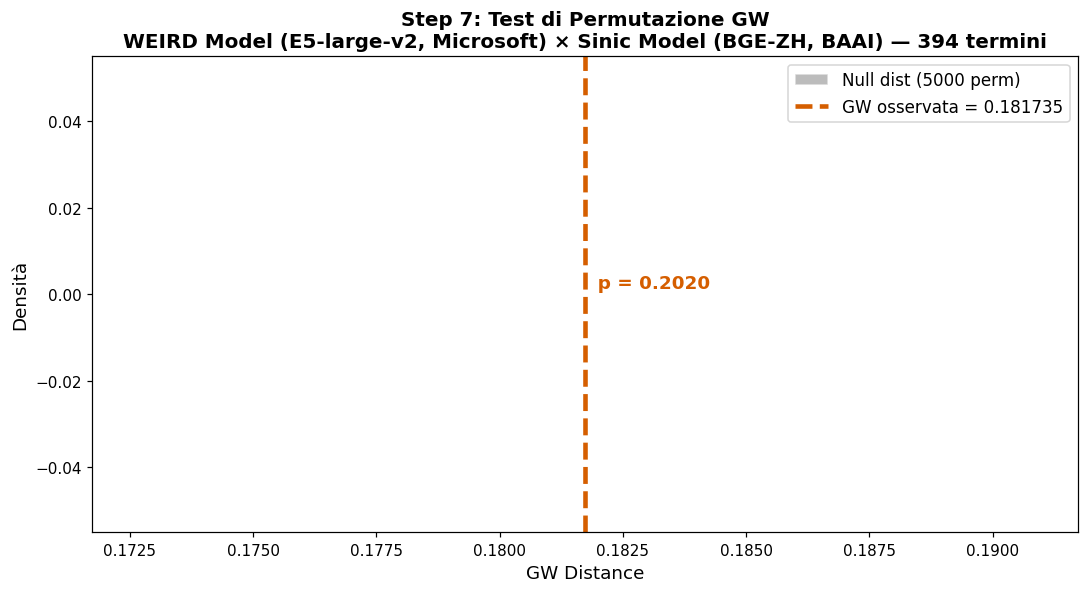

In [14]:
fig, ax = plt.subplots(figsize=(10, 5.5))

ax.hist(null_dists, bins=50, density=True, alpha=0.65, color='#999999',
        edgecolor='white', label=f'Null dist ({n_perm} perm)')
ax.axvline(gw_dist, color='#D55E00', linewidth=3, linestyle='--',
           label=f'GW osservata = {gw_dist:.6f}')

# Annotazione
ax.text(gw_dist, ax.get_ylim()[1] * 0.01, 
        f'  p = {p_value:.4f}',
        fontsize=12, color='#D55E00', fontweight='bold', va='bottom')

ax.set_xlabel('GW Distance', fontsize=12)
ax.set_ylabel('Densità', fontsize=12)
ax.set_title(f'Step 7: Test di Permutazione GW\n'
             f'{weird_cfg.label} × {sinic_cfg.label} — {n} termini',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
fig.tight_layout()
plt.show()

## Step 8: Confronto RSA vs GW sugli stessi dati reali

In [15]:
rsa_r, rsa_p = spearmanr(d_w, d_s)

print(f"RSA (Spearman r):   {rsa_r:.4f}  (p={rsa_p:.2e})")
print(f"GW (distance):      {gw_dist:.8f}  (p={p_value:.4f})")
print()
print(f"RSA dice: le geometrie sono correlate (r={rsa_r:.4f})")
print(f"  → quantifica QUANTO le strutture sono correlate (scala -1 a +1)")
print(f"  → non fornisce un piano di allineamento")
print()
print(f"GW dice: la distorsione per allinearle è {gw_dist:.8f}")
print(f"  → quantifica QUANTO costa allineare (scala 0 a +∞)")
print(f"  → fornisce il piano di trasporto T (chi mappa su chi)")
print(f"  → identifica DOVE la distorsione è maggiore")

RSA (Spearman r):   0.2407  (p=0.00e+00)
GW (distance):      0.18173514  (p=0.2020)

RSA dice: le geometrie sono correlate (r=0.2407)
  → quantifica QUANTO le strutture sono correlate (scala -1 a +1)
  → non fornisce un piano di allineamento

GW dice: la distorsione per allinearle è 0.18173514
  → quantifica QUANTO costa allineare (scala 0 a +∞)
  → fornisce il piano di trasporto T (chi mappa su chi)
  → identifica DOVE la distorsione è maggiore


## Step 9: Verifica — confronto con la pipeline

Eseguiamo la funzione `gromov_wasserstein_distance()` della pipeline
per verificare che produce lo stesso risultato.

In [16]:
from src.experiments.exp_gw import gromov_wasserstein_distance

result = gromov_wasserstein_distance(
    emb_w, emb_s,
    entropic_reg=epsilon,
    use_sinkhorn=True,
    n_permutations=100,  # ridotto per velocità
    seed=config.random_seed,
)

print(f"Pipeline GW distance:  {result.distance:.8f}")
print(f"Notebook GW distance:  {gw_dist:.8f}")
print(f"Differenza:            {abs(result.distance - gw_dist):.2e}")
print()
print(f"Pipeline p-value:      {result.p_value:.4f} (100 perm)")
print(f"Notebook p-value:      {p_value:.4f} ({n_perm} perm)")
print()
print(f"Piano T uguale: {np.allclose(result.transport_plan, T)}")

[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   5 tasks      | elapsed:    5.8s
[Parallel(n_jobs=10)]: Done  12 tasks      | elapsed:    6.0s
[Parallel(n_jobs=10)]: Done  21 tasks      | elapsed:    6.1s
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    6.3s
[Parallel(n_jobs=10)]: Done  41 tasks      | elapsed:    6.5s
[Parallel(n_jobs=10)]: Done  52 tasks      | elapsed:    6.7s
[Parallel(n_jobs=10)]: Done  65 tasks      | elapsed:    6.9s
[Parallel(n_jobs=10)]: Done  78 tasks      | elapsed:    7.1s


Pipeline GW distance:  0.18173514
Notebook GW distance:  0.18173514
Differenza:            0.00e+00

Pipeline p-value:      0.2475 (100 perm)
Notebook p-value:      0.2020 (5000 perm)

Piano T uguale: True


[Parallel(n_jobs=10)]: Done  92 out of 100 | elapsed:    7.3s remaining:    0.6s
[Parallel(n_jobs=10)]: Done 100 out of 100 | elapsed:    7.4s finished


## Step 10: Esplorazione ε — Dove il test di permutazione recupera potere?

Il problema: con ε = 0.005 il piano T è quasi-uniforme, rendendo GW
invariante alle permutazioni (σ_null = 0). Testiamo valori di ε
progressivamente più bassi + il solver esatto (ε = 0).

Per ogni ε:
1. Calcoliamo GW e il piano T
2. Misuriamo la concentrazione di T (entropia, self-mapping)
3. Eseguiamo 200 permutazioni per stimare la varianza della null distribution

In [17]:
from joblib import Parallel, delayed
import time

epsilons = [0.01, 0.005, 0.001, 0.0005, 0.0001]
n_perm_test = 200  # permutazioni ridotte per esplorazione
n_jobs = os.cpu_count() or 4

rng_eps = np.random.RandomState(config.random_seed)
perm_seeds_eps = rng_eps.randint(0, 2**31, size=n_perm_test)

results_eps = []

for eps in epsilons:
    print(f"\n{'='*60}")
    print(f"ε = {eps}")
    print(f"{'='*60}")
    
    # 1. Calcolo GW
    t0 = time.time()
    try:
        T_eps, log_eps = ot.gromov.entropic_gromov_wasserstein(
            C1_64, C2_64, p, q,
            loss_fun='square_loss', epsilon=eps, log=True,
        )
        gw_eps = log_eps['gw_dist']
        converged = True
    except Exception as e:
        print(f"  ERRORE: {e}")
        results_eps.append({
            'epsilon': eps, 'gw_dist': np.nan, 'converged': False,
            'self_mapping': 0, 'entropy_ratio': 1.0, 'max_weight_mean': 1/n,
            'null_mean': np.nan, 'null_std': 0, 'p_value': np.nan, 'time_s': 0,
        })
        continue
    
    # 2. Analisi piano T
    T_eps_norm = T_eps / T_eps.sum(axis=1, keepdims=True)
    row_ent = -np.sum(T_eps_norm * np.log(T_eps_norm + 1e-30), axis=1)
    ent_ratio = (row_ent / np.log(n)).mean()
    mw_mean = T_eps_norm.max(axis=1).mean()
    self_map = sum(1 for i in range(n) if np.argmax(T_eps[i]) == i)
    
    print(f"  GW distance:     {gw_eps:.8f}")
    print(f"  Self-mapping:    {self_map}/{n} ({self_map/n:.0%})")
    print(f"  Entropia/max:    {ent_ratio:.2%}")
    print(f"  Max weight medio: {mw_mean:.4f} (uniforme={1/n:.4f})")
    
    # 3. Permutation test (200 perm)
    def _perm_eps(seed, eps_val=eps):
        rng_local = np.random.RandomState(seed)
        perm = rng_local.permutation(n)
        C2_p = C2_64[np.ix_(perm, perm)]
        try:
            _, log_p = ot.gromov.entropic_gromov_wasserstein(
                C1_64, C2_p, p, q,
                loss_fun='square_loss', epsilon=eps_val, log=True,
            )
            return log_p['gw_dist']
        except:
            return np.nan
    
    null_eps = np.array(
        Parallel(n_jobs=n_jobs, verbose=0)(
            delayed(_perm_eps)(s) for s in perm_seeds_eps
        )
    )
    null_eps = null_eps[~np.isnan(null_eps)]
    
    elapsed = time.time() - t0
    
    if len(null_eps) > 0:
        p_val = (np.sum(null_eps <= gw_eps) + 1) / (len(null_eps) + 1)
        print(f"  Null dist:       μ={null_eps.mean():.8f}, σ={null_eps.std():.8f}")
        print(f"  Null range:      [{null_eps.min():.8f}, {null_eps.max():.8f}]")
        print(f"  p-value:         {p_val:.4f}")
    else:
        p_val = np.nan
        print(f"  Null dist:       TUTTE FALLITE")
    
    print(f"  Tempo:           {elapsed:.1f}s")
    
    results_eps.append({
        'epsilon': eps, 'gw_dist': gw_eps, 'converged': converged,
        'self_mapping': self_map, 'entropy_ratio': ent_ratio,
        'max_weight_mean': mw_mean,
        'null_mean': null_eps.mean() if len(null_eps) > 0 else np.nan,
        'null_std': null_eps.std() if len(null_eps) > 0 else 0,
        'p_value': p_val, 'time_s': elapsed,
        'null_dists': null_eps,
    })


ε = 0.01
  GW distance:     0.18230479
  Self-mapping:    1/394 (0%)
  Entropia/max:    99.37%
  Max weight medio: 0.0042 (uniforme=0.0025)
  Null dist:       μ=0.18230479, σ=0.00000000
  Null range:      [0.18230479, 0.18230479]
  p-value:         0.4975
  Tempo:           3.6s

ε = 0.005
  GW distance:     0.18173514
  Self-mapping:    1/394 (0%)
  Entropia/max:    97.97%
  Max weight medio: 0.0056 (uniforme=0.0025)
  Null dist:       μ=0.18173514, σ=0.00000000
  Null range:      [0.18173514, 0.18173514]
  p-value:         0.2040
  Tempo:           3.8s

ε = 0.001
  GW distance:     0.18065593
  Self-mapping:    2/394 (1%)
  Entropia/max:    89.86%
  Max weight medio: 0.0130 (uniforme=0.0025)
  Null dist:       μ=0.18065593, σ=0.00000000
  Null range:      [0.18065593, 0.18065593]
  p-value:         0.9254
  Tempo:           27.4s

ε = 0.0005
  GW distance:     0.00000000
  Self-mapping:    1/394 (0%)
  Entropia/max:    nan%
  Max weight medio: nan (uniforme=0.0025)


/Users/gpuzio/Desktop/CODE/THESIS/cls_pipeline/.venv/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:498: RuntimeWarning: divide by zero encountered in divide
  v = b / KtransposeU
/Users/gpuzio/Desktop/CODE/THESIS/cls_pipeline/.venv/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:498: RuntimeWarning: overflow encountered in divide
  v = b / KtransposeU
/Users/gpuzio/Desktop/CODE/THESIS/cls_pipeline/.venv/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:506: UserWarning: Warning: numerical errors at iteration 0
  warnings.warn('Warning: numerical errors at iteration %d' % ii)
/Users/gpuzio/Desktop/CODE/THESIS/cls_pipeline/.venv/lib/python3.12/site-packages/ot/gromov/_bregman.py:218: UserWarning: Solver failed to produce a transport plan. You might want to increase the regularization parameter `epsilon`.
  warnings.warn("Solver failed to produce a transport plan. You might "
/var/folders/9h/9rgcllzs3zl98mk9r243sbrw0000gn/T/ipykernel_96240/2919526165.py:37: RuntimeWarning: 

  Null dist:       μ=0.00000000, σ=0.00000000
  Null range:      [0.00000000, 0.00000000]
  p-value:         1.0000
  Tempo:           3.3s

ε = 0.0001
  GW distance:     0.00000000
  Self-mapping:    1/394 (0%)
  Entropia/max:    nan%
  Max weight medio: nan (uniforme=0.0025)
  Null dist:       μ=0.00000000, σ=0.00000000
  Null range:      [0.00000000, 0.00000000]
  p-value:         1.0000
  Tempo:           3.3s


In [18]:
# GW ESATTO (senza regolarizzazione entropica)
print(f"\n{'='*60}")
print(f"GW ESATTO (ε = 0, solver non-regolarizzato)")
print(f"{'='*60}")

t0 = time.time()
T_exact, log_exact = ot.gromov.gromov_wasserstein(
    C1_64, C2_64, p, q,
    loss_fun='square_loss', log=True,
)
gw_exact = log_exact['gw_dist']
t_exact_single = time.time() - t0

# Analisi piano T esatto
T_exact_norm = T_exact / T_exact.sum(axis=1, keepdims=True)
row_ent_exact = -np.sum(T_exact_norm * np.log(T_exact_norm + 1e-30), axis=1)
ent_ratio_exact = (row_ent_exact / np.log(n)).mean()
mw_exact = T_exact_norm.max(axis=1).mean()
self_map_exact = sum(1 for i in range(n) if np.argmax(T_exact[i]) == i)

print(f"  GW distance:     {gw_exact:.8f}")
print(f"  Self-mapping:    {self_map_exact}/{n} ({self_map_exact/n:.0%})")
print(f"  Entropia/max:    {ent_ratio_exact:.2%}")
print(f"  Max weight medio: {mw_exact:.4f}")
print(f"  Tempo singolo:   {t_exact_single:.1f}s")

# Permutation test esatto (200 perm)
def _perm_exact(seed):
    rng_local = np.random.RandomState(seed)
    perm = rng_local.permutation(n)
    C2_p = C2_64[np.ix_(perm, perm)]
    try:
        _, log_p = ot.gromov.gromov_wasserstein(
            C1_64, C2_p, p, q,
            loss_fun='square_loss', log=True,
        )
        return log_p['gw_dist']
    except:
        return np.nan

print(f"\n  Esecuzione {n_perm_test} permutazioni esatte...")
t0 = time.time()
null_exact = np.array(
    Parallel(n_jobs=n_jobs, verbose=5)(
        delayed(_perm_exact)(s) for s in perm_seeds_eps
    )
)
null_exact = null_exact[~np.isnan(null_exact)]
elapsed_exact = time.time() - t0

if len(null_exact) > 0:
    p_val_exact = (np.sum(null_exact <= gw_exact) + 1) / (len(null_exact) + 1)
    print(f"  Null dist:       μ={null_exact.mean():.8f}, σ={null_exact.std():.8f}")
    print(f"  Null range:      [{null_exact.min():.8f}, {null_exact.max():.8f}]")
    print(f"  p-value:         {p_val_exact:.4f}")
else:
    p_val_exact = np.nan

print(f"  Tempo totale:    {elapsed_exact:.1f}s ({elapsed_exact/60:.1f} min)")

results_eps.append({
    'epsilon': 0, 'gw_dist': gw_exact, 'converged': True,
    'self_mapping': self_map_exact, 'entropy_ratio': ent_ratio_exact,
    'max_weight_mean': mw_exact,
    'null_mean': null_exact.mean() if len(null_exact) > 0 else np.nan,
    'null_std': null_exact.std() if len(null_exact) > 0 else 0,
    'p_value': p_val_exact, 'time_s': elapsed_exact,
    'null_dists': null_exact,
})


GW ESATTO (ε = 0, solver non-regolarizzato)
  GW distance:     0.17967965
  Self-mapping:    0/394 (0%)
  Entropia/max:    0.00%
  Max weight medio: 1.0000
  Tempo singolo:   0.1s

  Esecuzione 200 permutazioni esatte...


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  84 tasks      | elapsed:    1.2s


  Null dist:       μ=0.17967965, σ=0.00000000
  Null range:      [0.17967965, 0.17967965]
  p-value:         0.9453
  Tempo totale:    2.8s (0.0 min)


[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    2.6s finished


In [19]:
# Tabella riepilogativa
print(f"\n{'='*100}")
print(f"RIEPILOGO ESPLORAZIONE ε")
print(f"{'='*100}")
print(f"{'ε':>10s}  {'GW dist':>12s}  {'Self-map':>10s}  {'Ent/max':>10s}  {'Max wt':>10s}  {'σ_null':>12s}  {'p-value':>10s}  {'Tempo':>8s}")
print('-' * 100)
for r in results_eps:
    eps_str = f"{r['epsilon']:.4f}" if r['epsilon'] > 0 else "ESATTO"
    sm_str = f"{r['self_mapping']}/{n}" if r['converged'] else "N/A"
    print(f"{eps_str:>10s}  {r['gw_dist']:>12.8f}  {sm_str:>10s}  {r['entropy_ratio']:>9.2%}  "
          f"{r['max_weight_mean']:>10.4f}  {r['null_std']:>12.8f}  {r['p_value']:>10.4f}  {r['time_s']:>7.1f}s")


RIEPILOGO ESPLORAZIONE ε
         ε       GW dist    Self-map     Ent/max      Max wt        σ_null     p-value     Tempo
----------------------------------------------------------------------------------------------------
    0.0100    0.18230479       1/394     99.37%      0.0042    0.00000000      0.4975      3.6s
    0.0050    0.18173514       1/394     97.97%      0.0056    0.00000000      0.2040      3.8s
    0.0010    0.18065593       2/394     89.86%      0.0130    0.00000000      0.9254     27.4s
    0.0005    0.00000000       1/394       nan%         nan    0.00000000      1.0000      3.3s
    0.0001    0.00000000       1/394       nan%         nan    0.00000000      1.0000      3.3s
    ESATTO    0.17967965       0/394      0.00%      1.0000    0.00000000      0.9453      2.8s


/Users/gpuzio/Desktop/CODE/THESIS/cls_pipeline/.venv/lib/python3.12/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
/Users/gpuzio/Desktop/CODE/THESIS/cls_pipeline/.venv/lib/python3.12/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


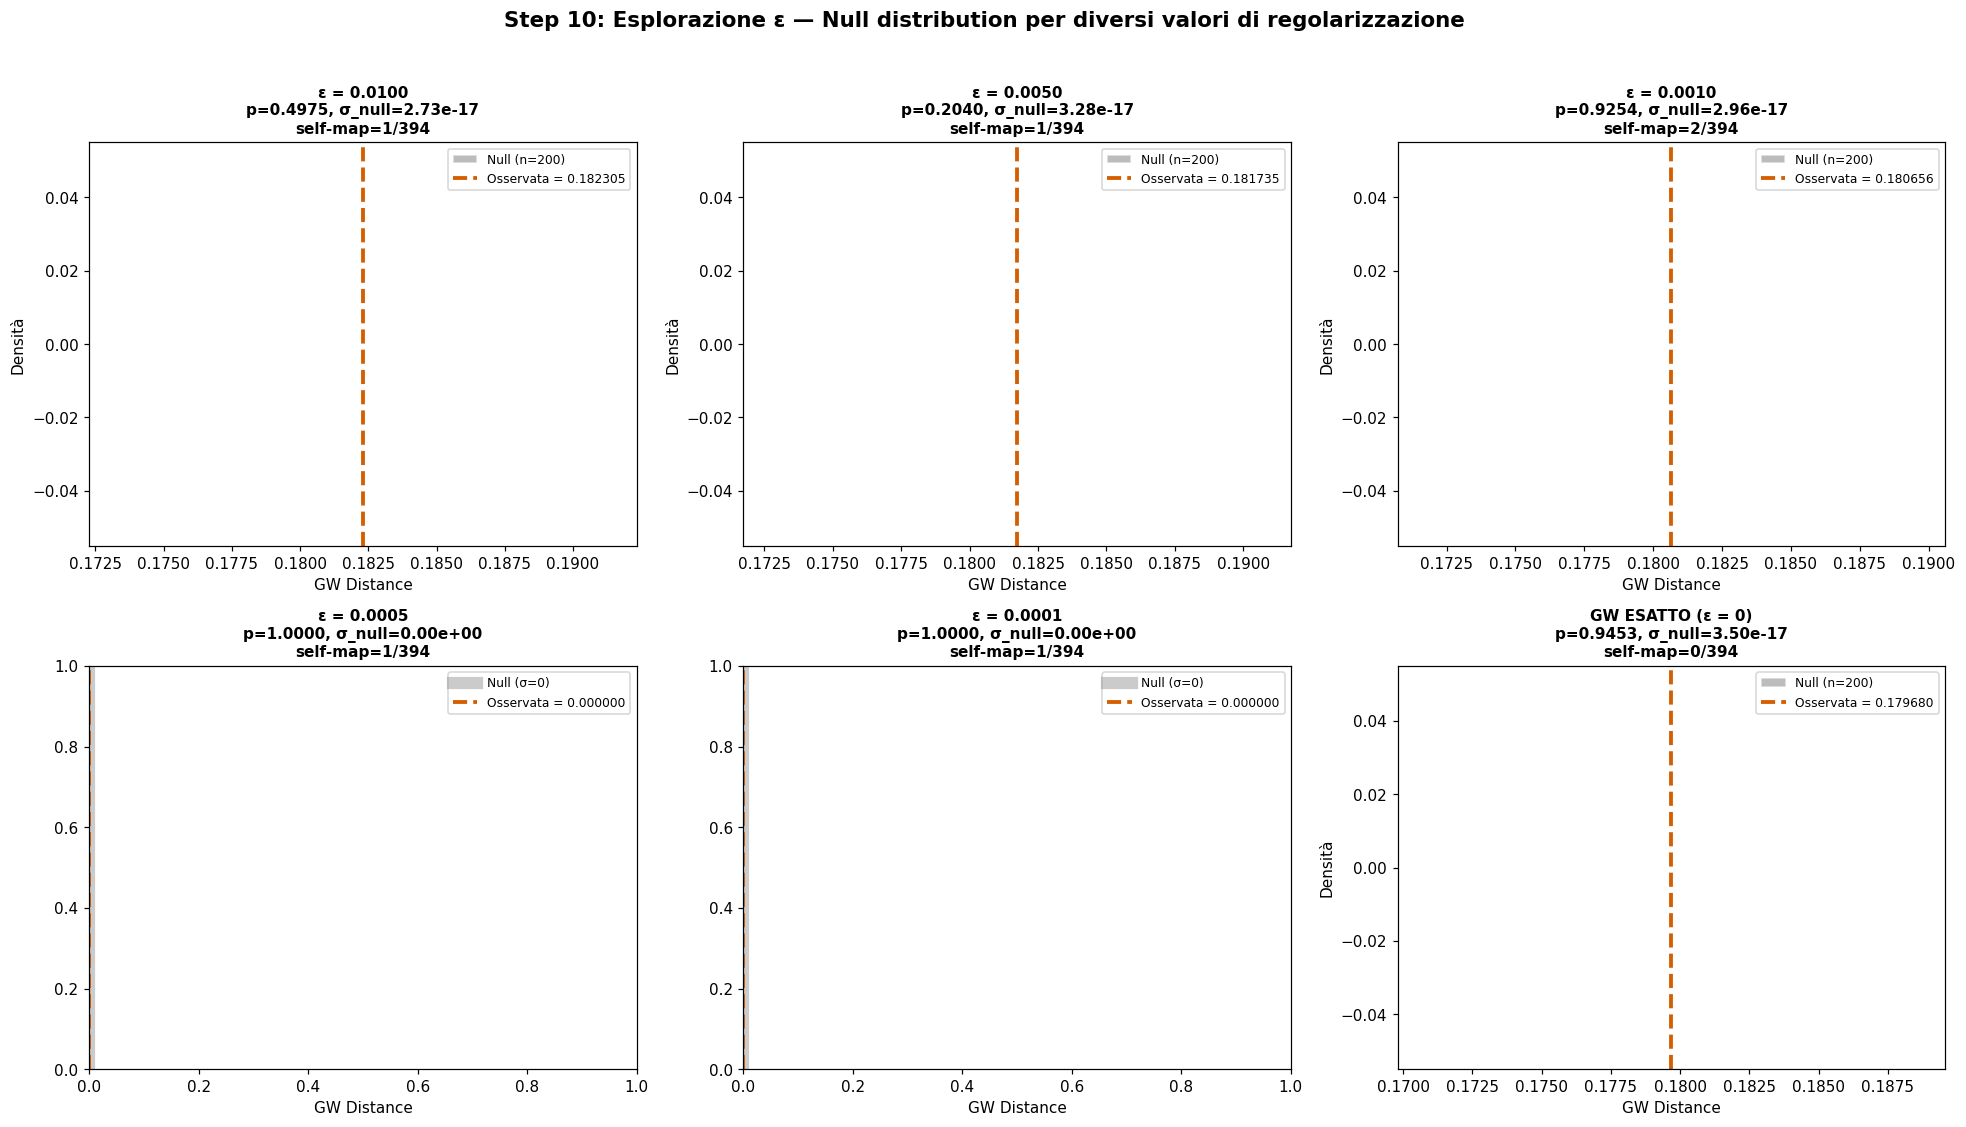

In [20]:
# Visualizzazione: null distribution per ogni ε
valid_results = [r for r in results_eps if r['converged'] and r['null_std'] >= 0]
n_plots = len(valid_results)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, r in enumerate(valid_results):
    ax = axes[idx]
    eps_label = f"ε = {r['epsilon']:.4f}" if r['epsilon'] > 0 else "GW ESATTO (ε = 0)"
    null = r.get('null_dists', np.array([]))
    
    if len(null) > 0 and null.std() > 0:
        ax.hist(null, bins=30, density=True, alpha=0.65, color='#999999',
                edgecolor='white', label=f'Null (n={len(null)})')
        ax.axvline(r['gw_dist'], color='#D55E00', linewidth=2.5, linestyle='--',
                   label=f'Osservata = {r["gw_dist"]:.6f}')
        ax.set_ylabel('Densità')
    elif len(null) > 0:
        # Null degenere (σ=0): mostra come barra singola
        ax.axvline(null[0], color='#999999', linewidth=8, alpha=0.5, label='Null (σ=0)')
        ax.axvline(r['gw_dist'], color='#D55E00', linewidth=2.5, linestyle='--',
                   label=f'Osservata = {r["gw_dist"]:.6f}')
    
    ax.set_title(f'{eps_label}\np={r["p_value"]:.4f}, σ_null={r["null_std"]:.2e}\n'
                 f'self-map={r["self_mapping"]}/{n}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('GW Distance')
    ax.legend(fontsize=8)

# Nascondo assi vuoti se meno di 6 plot
for idx in range(n_plots, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Step 10: Esplorazione ε — Null distribution per diversi valori di regolarizzazione',
             fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()